# Step 1: Portfolio QUBO — 4 Assets, 4 Qubits (Hartford Sectors)
## YQuantum 2026 — Capgemini / The Hartford Challenge

**Goal:** Build the QUBO for 4 assets (1 qubit each), compute the ground truth, visualize the probability distribution, convert to Ising, and prepare everything for QAOA on Bloqade.

**Scaling plan:** Start here with 4 qubits → then scale to 8 qubits in Step 2.

---

In [7]:
pip install openpyxl 

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Load Dataset

In [9]:
xlsx_path = 'investment_dataset_full.xlsx'

assets_all = pd.read_excel(xlsx_path, sheet_name='assets')
cov_df = pd.read_excel(xlsx_path, sheet_name='covariance', index_col=0)
corr_df = pd.read_excel(xlsx_path, sheet_name='correlation', index_col=0)
scenarios = pd.read_excel(xlsx_path, sheet_name='scenarios')

assets_all['sharpe'] = assets_all['exp_return'] / assets_all['volatility']

print(f'Dataset: {assets_all.shape[0]} assets, {scenarios.shape[0]} scenarios')
print(f'Sectors: {assets_all["sector"].nunique()}')
print(assets_all['sector'].value_counts().to_string())

Dataset: 50 assets, 1200 scenarios
Sectors: 8
sector
IG Credit         12
Equities US       10
HY Credit         10
Equities Intl      7
Gov Bonds          5
Cash               3
Real Estate        2
Infrastructure     1


## 2. Select 4 Assets (Hartford-Relevant Sectors)

In [10]:
target_sectors = ['Gov Bonds', 'IG Credit', 'Cash', 'HY Credit']

sel4 = []
for sector in target_sectors:
    subset = assets_all[assets_all['sector'] == sector]
    best = subset.loc[subset['sharpe'].idxmax()]
    sel4.append(best)

sel4_df = pd.DataFrame(sel4).set_index('asset_id')
sel4_ids = sel4_df.index.tolist()
sectors = sel4_df['sector'].tolist()

mu = sel4_df['exp_return'].values
w_max = sel4_df['w_max'].values
cov4 = cov_df.loc[sel4_ids, sel4_ids].values
corr4 = corr_df.loc[sel4_ids, sel4_ids].values
n = 4

print('Selected Assets (best Sharpe ratio per sector):')
sel4_df[['sector', 'rating', 'exp_return', 'volatility', 'sharpe',
         'liquidity', 'capital_charge', 'w_max']].round(4)

Selected Assets (best Sharpe ratio per sector):


,sector,rating,exp_return,volatility,sharpe,liquidity,capital_charge,w_max
asset_id,,,,,,,,
A017,Gov Bonds,AA,0.0183,0.0364,0.5031,4,0.010,0.20
A026,IG Credit,A,0.0334,0.0508,0.6576,4,0.020,0.12
A007,Cash,NaN,0.0164,0.0121,1.3532,4,0.005,0.25
A047,HY Credit,B,0.0730,0.1132,0.6446,3,0.070,0.06


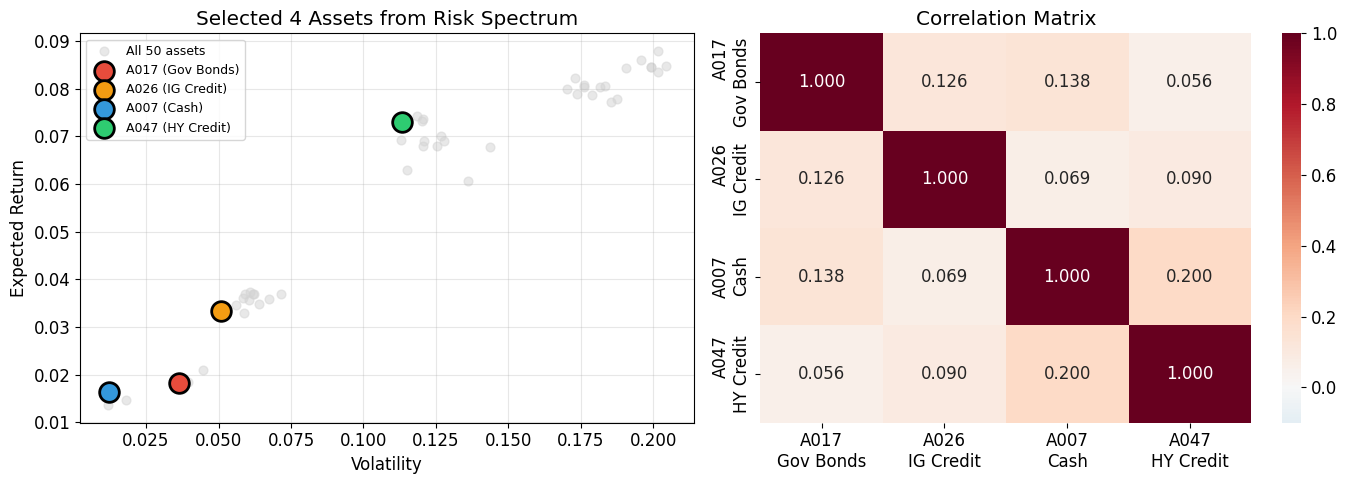

In [11]:
# Risk-return plot for selected assets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All assets + selected highlighted
axes[0].scatter(assets_all['volatility'], assets_all['exp_return'],
               c='lightgray', s=40, alpha=0.5, label='All 50 assets')
colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
for i, (sid, sec) in enumerate(zip(sel4_ids, sectors)):
    row = sel4_df.loc[sid]
    axes[0].scatter(row['volatility'], row['exp_return'], c=colors[i],
                   s=200, edgecolors='black', linewidth=2, zorder=5, label=f'{sid} ({sec})')
axes[0].set_xlabel('Volatility')
axes[0].set_ylabel('Expected Return')
axes[0].set_title('Selected 4 Assets from Risk Spectrum')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Correlation heatmap
labels = [f'{sid}\n{sec}' for sid, sec in zip(sel4_ids, sectors)]
sns.heatmap(corr4, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            xticklabels=labels, yticklabels=labels, vmin=-0.1, vmax=1, ax=axes[1])
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

## 3. The Cost Function

The Markowitz objective balances three competing forces:

$$\text{minimize:} \quad \underbrace{q \cdot \mathbf{w}^T \Sigma \mathbf{w}}_{\text{risk penalty}} \;-\; \underbrace{\boldsymbol{\mu}^T \mathbf{w}}_{\text{return reward}} \;+\; \underbrace{\lambda(\sum w_i - B)^2}_{\text{budget enforcement}}$$

- **Risk** pushes weights down (less investment = less risk)
- **Return** pushes weights up (more investment = more profit)
- **Budget** forces total investment to equal $B$ (prevents "invest nothing")

For the QUBO: $w_i = x_i \cdot w_{max,i}$ where $x_i \in \{0, 1\}$

In [12]:
# Show why budget penalty is essential
B = 0.30  # target budget
q_risk = 1.0
lam = 10.0

print('=== Why the Budget Penalty Matters ===')
print(f'Parameters: q={q_risk}, λ={lam}, B={B}')
print()

test_states = {
    'Invest nothing [0,0,0,0]': np.array([0,0,0,0], dtype=float),
    'Only bonds     [1,0,0,0]': np.array([1,0,0,0], dtype=float),
    'Bonds+HY       [1,0,0,1]': np.array([1,0,0,1], dtype=float),
    'All assets     [1,1,1,1]': np.array([1,1,1,1], dtype=float),
}

print(f'{"State":>30} {"Risk":>8} {"Return":>8} {"Penalty":>8} {"TOTAL":>8}')
print('-' * 70)
for name, x in test_states.items():
    w = x * w_max
    risk = q_risk * w @ cov4 @ w
    ret = mu @ w
    penalty = lam * (w.sum() - B)**2
    total = risk - ret + penalty
    print(f'{name:>30} {risk:>8.4f} {ret:>8.4f} {penalty:>8.4f} {total:>8.4f}')

print(f'\n→ Investing nothing gets the WORST score because of the {lam}*(0-{B})²={lam*B**2:.2f} penalty')

=== Why the Budget Penalty Matters ===
Parameters: q=1.0, λ=10.0, B=0.3

                         State     Risk   Return  Penalty    TOTAL
----------------------------------------------------------------------
      Invest nothing [0,0,0,0]   0.0000   0.0000   0.9000   0.9000
      Only bonds     [1,0,0,0]   0.0001   0.0037   0.1000   0.0964
      Bonds+HY       [1,0,0,1]   0.0001   0.0080   0.0160   0.0081
      All assets     [1,1,1,1]   0.0002   0.0161   1.0890   1.0730

→ Investing nothing gets the WORST score because of the 10.0*(0-0.3)²=0.90 penalty


## 4. Build the QUBO Matrix

In [13]:
def build_qubo(mu, cov, w_max, q_risk, lam, B):
    """
    Build QUBO matrix for binary portfolio selection.
    
    x_i in {0,1}, w_i = x_i * w_max_i
    
    Q_ii = q*σ_ii*w_i² - μ_i*w_i + λ*w_i² - 2λB*w_i
    Q_ij = q*σ_ij*w_i*w_j + λ*w_i*w_j   (i ≠ j)
    offset = λB²
    """
    n = len(mu)
    Q = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            Q[i][j] = q_risk * cov[i][j] * w_max[i] * w_max[j]
            Q[i][j] += lam * w_max[i] * w_max[j]
        Q[i][i] -= mu[i] * w_max[i]
        Q[i][i] -= 2 * lam * B * w_max[i]
    
    offset = lam * B**2
    Q = (Q + Q.T) / 2
    return Q, offset


Q, offset = build_qubo(mu, cov4, w_max, q_risk, lam, B)

print(f'QUBO Parameters: q={q_risk}, λ={lam}, B={B}')
print(f'Offset (λB²) = {offset:.4f}')
print(f'\n4×4 QUBO Matrix Q:')
print(np.round(Q, 6))

QUBO Parameters: q=1.0, λ=10.0, B=0.3
Offset (λB²) = 0.9000

4×4 QUBO Matrix Q:
[[-0.803612  0.240006  0.500003  0.120003]
 [ 0.240006 -0.57997   0.300001  0.072004]
 [ 0.500003  0.300001 -0.879089  0.150004]
 [ 0.120003  0.072004  0.150004 -0.328333]]


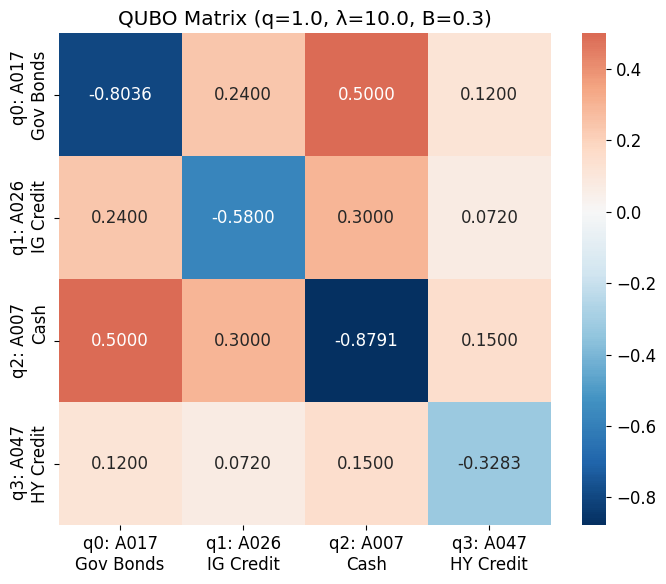

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
labels = [f'q{i}: {sel4_ids[i]}\n{sectors[i]}' for i in range(n)]
sns.heatmap(Q, annot=True, fmt='.4f', cmap='RdBu_r', center=0,
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title(f'QUBO Matrix (q={q_risk}, λ={lam}, B={B})')
plt.tight_layout()
plt.show()

## 5. Brute-Force All 16 States

In [15]:
all_results = []
for bits in range(2**n):
    x = np.array([(bits >> i) & 1 for i in range(n)], dtype=float)
    w = x * w_max
    obj = float(x @ Q @ x + offset)
    ret = float(mu @ w)
    risk = float(np.sqrt(max(w @ cov4 @ w, 0)))
    
    all_results.append({
        'x': x.astype(int).tolist(),
        'label': ''.join(map(str, x.astype(int).tolist())),
        'objective': round(obj, 6),
        'total_weight': round(w.sum(), 4),
        'return': round(ret, 6),
        'risk': round(risk, 6),
        'n_assets': int(x.sum())
    })

all_results.sort(key=lambda r: r['objective'])

print(f'=== All 16 Portfolios (sorted by objective) ===')
print(f'Budget target B = {B}')
print(f'{"Rank":>4} {"State":>8} {"Σw":>6} {"Return":>9} {"Risk":>9} {"Objective":>10}')
print('-' * 55)
for i, r in enumerate(all_results):
    marker = ' ◀ BEST' if i == 0 else ''
    if r['label'] == '0000': marker = ' ◀ WORST (nothing)'
    print(f"{i+1:>4} {r['label']:>8} {r['total_weight']:>6.3f} "
          f"{r['return']:>9.6f} {r['risk']:>9.6f} {r['objective']:>10.6f}{marker}")

ground = all_results[0]
sel_names = [f'{sel4_ids[i]}({sectors[i][:5]})' for i in range(n) if ground['x'][i]==1]
print(f'\nGround state: x={ground["x"]} → {sel_names}')
print(f'Total weight: {ground["total_weight"]:.3f} (target: {B})')

=== All 16 Portfolios (sorted by objective) ===
Budget target B = 0.3
Rank    State     Σw    Return      Risk  Objective
-------------------------------------------------------
   1     0011  0.310  0.008477  0.007973  -0.007414 ◀ BEST
   2     1100  0.320  0.007672  0.010071  -0.003571
   3     1001  0.260  0.008045  0.010237   0.008060
   4     0010  0.250  0.004098  0.003028   0.020911
   5     0110  0.370  0.008105  0.006990   0.040944
   6     1101  0.380  0.012052  0.012673   0.052109
   7     1000  0.200  0.003665  0.007286   0.096388
   8     0101  0.180  0.008387  0.009526   0.135704
   9     0111  0.430  0.012485  0.010523   0.156626
  10     1010  0.450  0.007763  0.008267   0.217305
  11     0100  0.120  0.004007  0.006094   0.320030
  12     1011  0.510  0.012143  0.011327   0.428986
  13     0001  0.060  0.004380  0.006794   0.571667
  14     1110  0.570  0.011770  0.010921   0.717349
  15     0000  0.000  0.000000  0.000000   0.900000 ◀ WORST (nothing)
  16     1111  0.

## 6. Probability Distribution

A quantum computer doesn't give one answer — it gives a **probability distribution** over all possible states. The ground state should have the highest probability.

We simulate this at three levels:
1. **Ideal** — perfect QAOA, ground state dominates
2. **Realistic** — limited QAOA layers, some spread
3. **Measurement** — finite shots sampling from the distribution

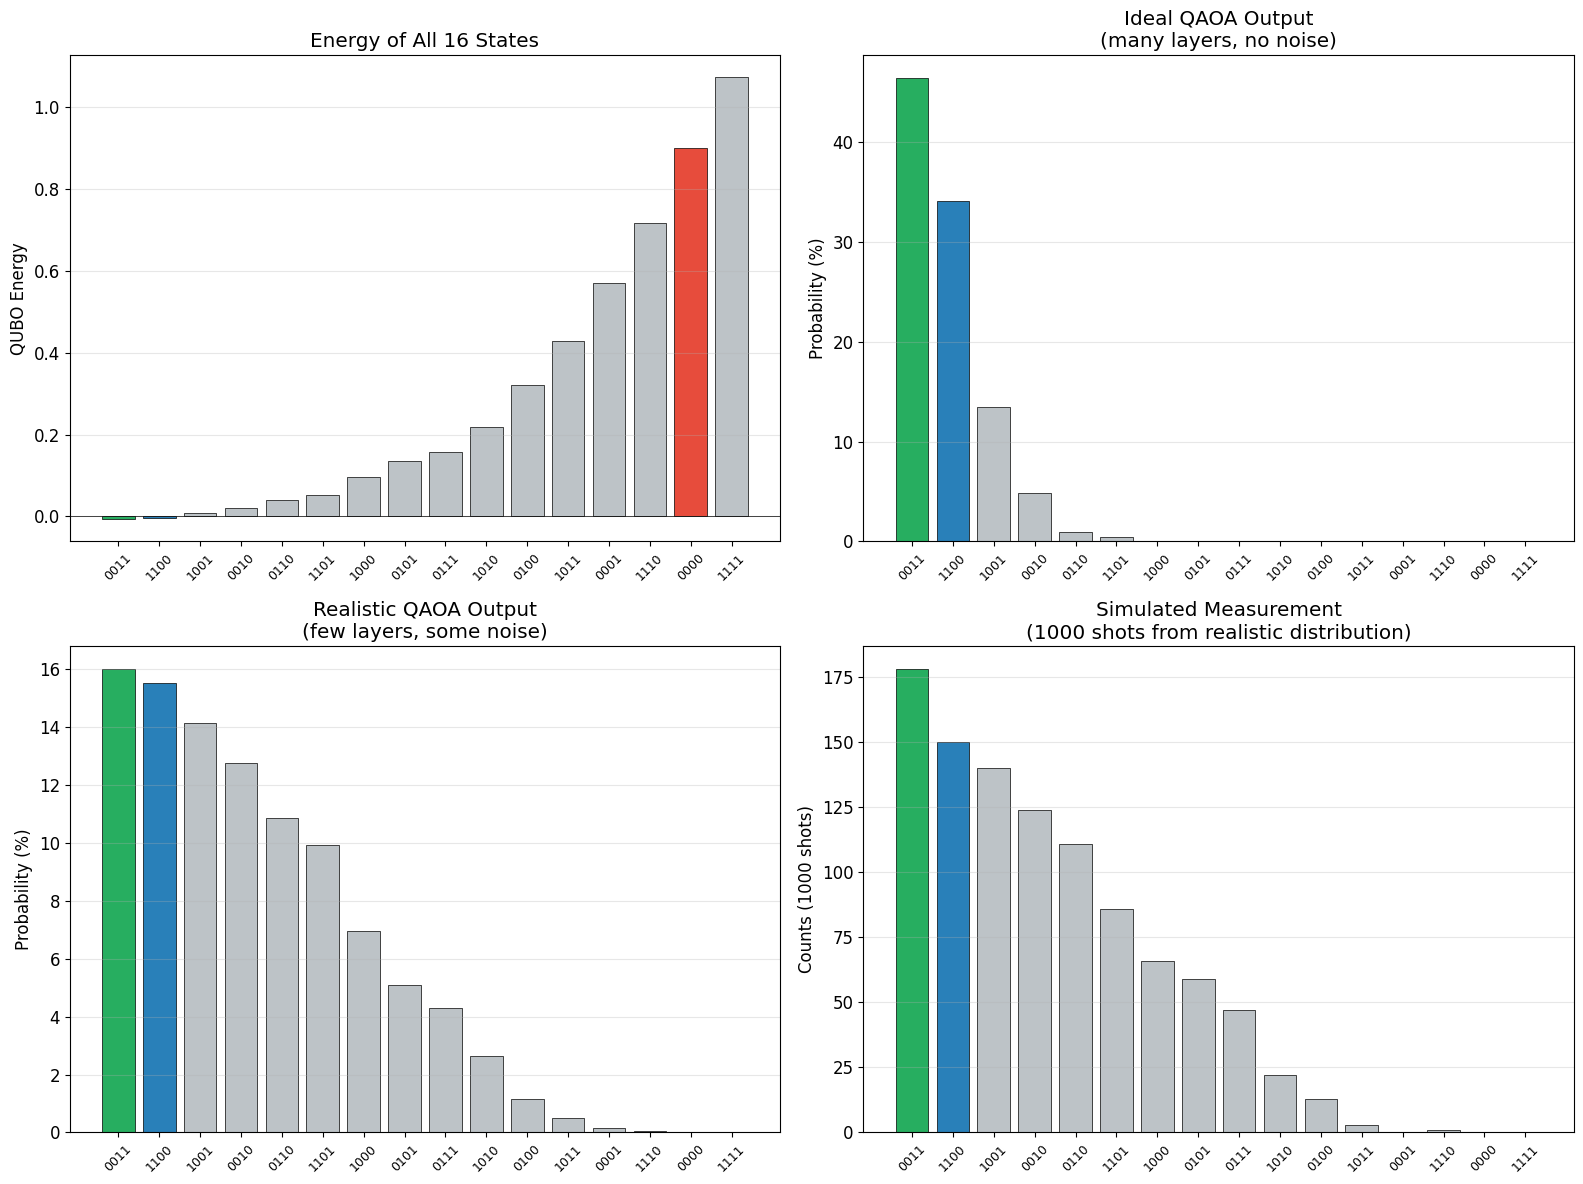

Rank    State     Energy   Ideal%    Real%   Counts
-------------------------------------------------------
   1     0011    -0.0074   46.32%   15.98%      178
   2     1100    -0.0036   34.06%   15.50%      150
   3     1001     0.0081   13.43%   14.12%      140
   4     0010     0.0209    4.80%   12.74%      124
   5     0110     0.0409    0.97%   10.86%      111
   6     1101     0.0521    0.40%    9.93%       86
   7     1000     0.0964    0.01%    6.97%       66
   8     0101     0.1357    0.00%    5.09%       59
   9     0111     0.1566    0.00%    4.30%       47
  10     1010     0.2173    0.00%    2.65%       22
  11     0100     0.3200    0.00%    1.16%       13
  12     1011     0.4290    0.00%    0.49%        3
  13     0001     0.5717    0.00%    0.16%        0
  14     1110     0.7173    0.00%    0.05%        1
  15     0000     0.9000    0.00%    0.01%        0
  16     1111     1.0730    0.00%    0.00%        0


In [16]:
energies = np.array([r['objective'] for r in all_results])
state_labels = [r['label'] for r in all_results]

# Color scheme: green=ground state, red=invest nothing, blue=others
bar_colors = []
for i, r in enumerate(all_results):
    if i == 0:
        bar_colors.append('#27ae60')  # ground state
    elif r['label'] == '0000':
        bar_colors.append('#e74c3c')  # invest nothing
    elif r['objective'] < 0:
        bar_colors.append('#2980b9')  # negative energy (good)
    else:
        bar_colors.append('#bdc3c7')  # positive energy (bad)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Energy landscape ---
axes[0][0].bar(range(16), energies, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0][0].set_xticks(range(16))
axes[0][0].set_xticklabels(state_labels, rotation=45, fontsize=9)
axes[0][0].set_ylabel('QUBO Energy')
axes[0][0].set_title('Energy of All 16 States')
axes[0][0].axhline(0, color='black', linewidth=0.5)
axes[0][0].grid(True, alpha=0.3, axis='y')

# --- Plot 2: Ideal QAOA probability ---
beta_ideal = 80
boltz_ideal = np.exp(-beta_ideal * (energies - energies.min()))
prob_ideal = boltz_ideal / boltz_ideal.sum()

axes[0][1].bar(range(16), prob_ideal * 100, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[0][1].set_xticks(range(16))
axes[0][1].set_xticklabels(state_labels, rotation=45, fontsize=9)
axes[0][1].set_ylabel('Probability (%)')
axes[0][1].set_title('Ideal QAOA Output\n(many layers, no noise)')
axes[0][1].grid(True, alpha=0.3, axis='y')

# --- Plot 3: Realistic QAOA probability ---
beta_real = 8
boltz_real = np.exp(-beta_real * (energies - energies.min()))
prob_real = boltz_real / boltz_real.sum()

axes[1][0].bar(range(16), prob_real * 100, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1][0].set_xticks(range(16))
axes[1][0].set_xticklabels(state_labels, rotation=45, fontsize=9)
axes[1][0].set_ylabel('Probability (%)')
axes[1][0].set_title('Realistic QAOA Output\n(few layers, some noise)')
axes[1][0].grid(True, alpha=0.3, axis='y')

# --- Plot 4: Simulated shots ---
shots = 1000
samples = np.random.choice(range(16), size=shots, p=prob_real)
counts = np.bincount(samples, minlength=16)

axes[1][1].bar(range(16), counts, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1][1].set_xticks(range(16))
axes[1][1].set_xticklabels(state_labels, rotation=45, fontsize=9)
axes[1][1].set_ylabel(f'Counts ({shots} shots)')
axes[1][1].set_title(f'Simulated Measurement\n({shots} shots from realistic distribution)')
axes[1][1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print(f'{"Rank":>4} {"State":>8} {"Energy":>10} {"Ideal%":>8} {"Real%":>8} {"Counts":>8}')
print('-' * 55)
for i in range(16):
    print(f"{i+1:>4} {state_labels[i]:>8} {energies[i]:>10.4f} "
          f"{prob_ideal[i]*100:>7.2f}% {prob_real[i]*100:>7.2f}% {counts[i]:>8}")

## 7. How Risk Aversion Changes the Solution

In [17]:
# Sweep budget B to show non-trivial behavior
print('=== Optimal Portfolio vs Budget Target ===')
print(f'{"B":>5} {"Best x":>12} {"Selected":>40} {"Σw":>6} {"Ret":>9} {"Risk":>9}')
print('-' * 90)

for B_val in np.arange(0.06, 0.48, 0.02):
    Q_tmp, off_tmp = build_qubo(mu, cov4, w_max, q_risk, lam, B_val)
    best_obj = float('inf')
    best_x = None
    for bits in range(16):
        x = np.array([(bits >> i) & 1 for i in range(n)], dtype=float)
        obj = x @ Q_tmp @ x + off_tmp
        if obj < best_obj:
            best_obj = obj
            best_x = x.astype(int).tolist()
    w = np.array(best_x) * w_max
    sel = [f'{sel4_ids[i][:4]}' for i in range(n) if best_x[i]==1]
    print(f"{B_val:>5.2f} {str(best_x):>12} {', '.join(sel):>40} "
          f"{w.sum():>6.3f} {float(mu@w):>9.6f} {float(np.sqrt(max(w@cov4@w,0))):>9.6f}")

print(f'\nDifferent budgets select different asset combinations.')
print(f'This is what the quantum optimizer must navigate.')

=== Optimal Portfolio vs Budget Target ===
    B       Best x                                 Selected     Σw       Ret      Risk
------------------------------------------------------------------------------------------
 0.06 [0, 0, 0, 1]                                     A047  0.060  0.004380  0.006794
 0.08 [0, 0, 0, 1]                                     A047  0.060  0.004380  0.006794
 0.10 [0, 1, 0, 0]                                     A026  0.120  0.004007  0.006094
 0.12 [0, 1, 0, 0]                                     A026  0.120  0.004007  0.006094
 0.14 [0, 1, 0, 0]                                     A026  0.120  0.004007  0.006094
 0.16 [0, 1, 0, 1]                               A026, A047  0.180  0.008387  0.009526
 0.18 [0, 1, 0, 1]                               A026, A047  0.180  0.008387  0.009526
 0.20 [0, 1, 0, 1]                               A026, A047  0.180  0.008387  0.009526
 0.22 [1, 0, 0, 0]                                     A017  0.200  0.003665  0.007

## 8. QUBO → Ising Conversion

In [18]:
def qubo_to_ising(Q):
    """Convert QUBO to Ising: H = Σ J_ij s_i s_j + Σ h_i s_i + const"""
    n = Q.shape[0]
    J = np.zeros((n, n))
    h = np.zeros(n)
    ising_offset = 0.0
    for i in range(n):
        for j in range(i+1, n):
            J[i][j] = Q[i][j] / 4.0
        h[i] = Q[i][i] / 2.0 + sum(Q[i][j] / 4.0 for j in range(n) if j != i)
        ising_offset += Q[i][i] / 4.0
    ising_offset += sum(Q[i][j] / 4.0 for i in range(n) for j in range(i+1, n))
    return J, h, ising_offset


J, h, ising_offset = qubo_to_ising(Q)

print('=== Ising Hamiltonian ===')
print(f'H = Σ J_ij s_i s_j + Σ h_i s_i + const')
print(f'where s_i ∈ {{-1, +1}}, related to QUBO by x_i = (1 + s_i)/2')
print(f'\nLocal fields h:')
for i in range(n):
    print(f'  h[{i}] ({sel4_ids[i]:>4}, {sectors[i]:>12}) = {h[i]:>10.6f}')

print(f'\nCouplings J:')
for i in range(n):
    for j in range(i+1, n):
        print(f'  J[{i},{j}] ({sel4_ids[i]}-{sel4_ids[j]}) = {J[i][j]:.6f}')

print(f'\nIsing offset: {ising_offset:.6f}')
print(f'QUBO offset:  {offset:.6f}')
print(f'Total const:  {ising_offset + offset:.6f}')

=== Ising Hamiltonian ===
H = Σ J_ij s_i s_j + Σ h_i s_i + const
where s_i ∈ {-1, +1}, related to QUBO by x_i = (1 + s_i)/2

Local fields h:
  h[0] (A017,    Gov Bonds) =  -0.186803
  h[1] (A026,    IG Credit) =  -0.136982
  h[2] (A007,         Cash) =  -0.202042
  h[3] (A047,    HY Credit) =  -0.078664

Couplings J:
  J[0,1] (A017-A026) = 0.060001
  J[0,2] (A017-A007) = 0.125001
  J[0,3] (A017-A047) = 0.030001
  J[1,2] (A026-A007) = 0.075000
  J[1,3] (A026-A047) = 0.018001
  J[2,3] (A007-A047) = 0.037501

Ising offset: -0.302246
QUBO offset:  0.900000
Total const:  0.597754


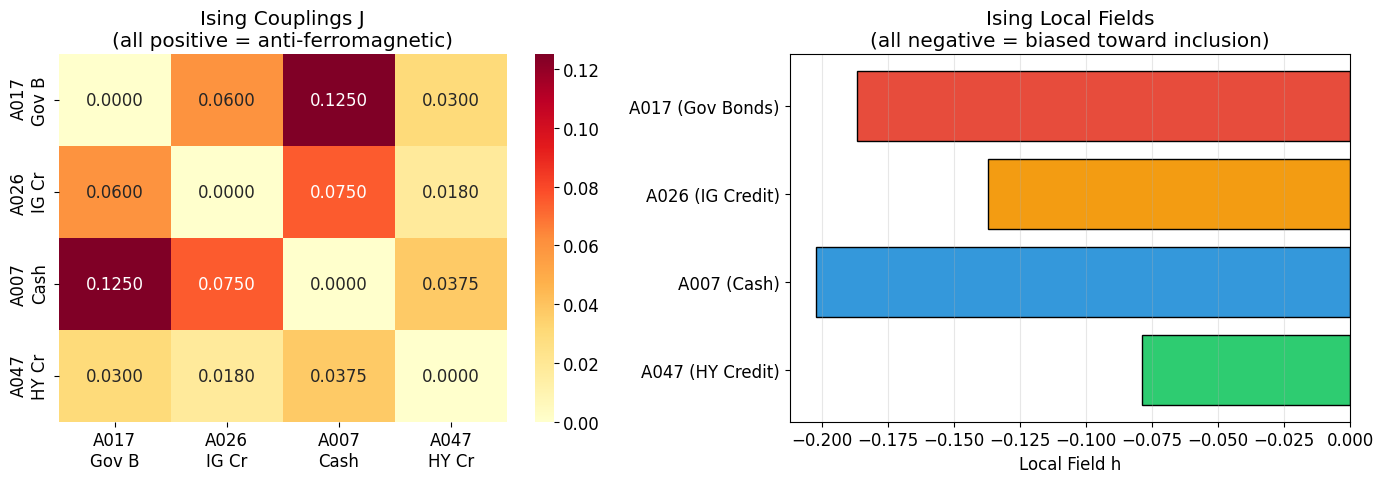

In [19]:
# Visualize Ising structure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# J coupling heatmap
J_sym = J + J.T
labels_short = [f'{sel4_ids[i]}\n{sectors[i][:5]}' for i in range(n)]
sns.heatmap(J_sym, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=labels_short, yticklabels=labels_short, ax=axes[0])
axes[0].set_title('Ising Couplings J\n(all positive = anti-ferromagnetic)')

# h field bar chart
asset_colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
axes[1].barh(range(n), h, color=asset_colors, edgecolor='black')
axes[1].set_yticks(range(n))
axes[1].set_yticklabels([f'{sel4_ids[i]} ({sectors[i]})' for i in range(n)])
axes[1].set_xlabel('Local Field h')
axes[1].set_title('Ising Local Fields\n(all negative = biased toward inclusion)')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 9. Scenario Validation (1,200 Simulations)

Optimal portfolio: x=[0, 0, 1, 1]
Weights: [0.0, 0.0, 0.25, 0.06]

--- 1,200 Scenario Analysis ---
Mean return:  0.000035
Std dev:      0.000501
VaR (95%):    -0.000773
CVaR (95%):   -0.000979


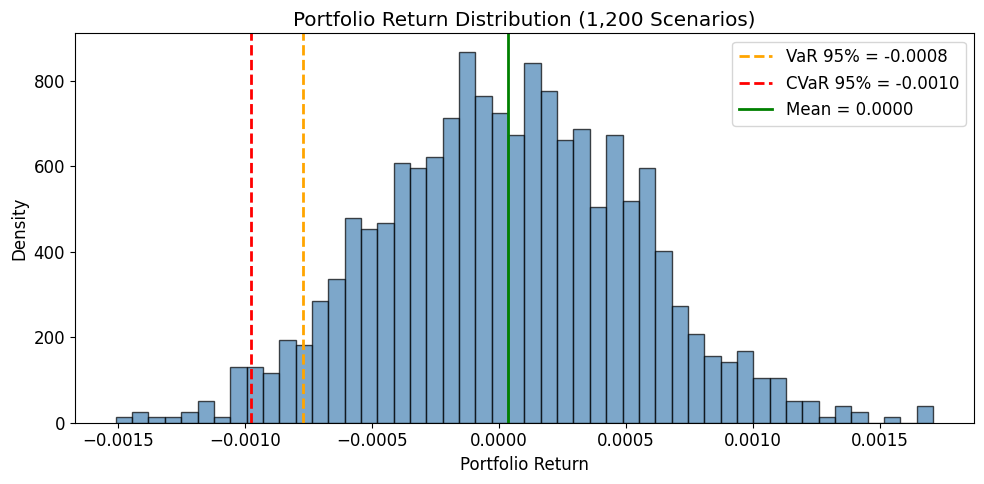

In [20]:
ground = all_results[0]
w_opt = np.array(ground['x']) * w_max

scenario_rets = scenarios[sel4_ids].values @ w_opt
var_95 = np.percentile(scenario_rets, 5)
cvar_95 = scenario_rets[scenario_rets <= var_95].mean()

print(f'Optimal portfolio: x={ground["x"]}')
print(f'Weights: {np.round(w_opt, 4).tolist()}')
print(f'\n--- 1,200 Scenario Analysis ---')
print(f'Mean return:  {scenario_rets.mean():.6f}')
print(f'Std dev:      {scenario_rets.std():.6f}')
print(f'VaR (95%):    {var_95:.6f}')
print(f'CVaR (95%):   {cvar_95:.6f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scenario_rets, bins=50, color='steelblue', edgecolor='black', alpha=0.7, density=True)
ax.axvline(var_95, color='orange', ls='--', lw=2, label=f'VaR 95% = {var_95:.4f}')
ax.axvline(cvar_95, color='red', ls='--', lw=2, label=f'CVaR 95% = {cvar_95:.4f}')
ax.axvline(scenario_rets.mean(), color='green', lw=2, label=f'Mean = {scenario_rets.mean():.4f}')
ax.set_xlabel('Portfolio Return')
ax.set_ylabel('Density')
ax.set_title('Portfolio Return Distribution (1,200 Scenarios)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Save Everything for Step 2 (Bloqade QAOA)

In [21]:
handoff = {
    'encoding': '4 assets x 1 qubit each (binary)',
    'assets': sel4_ids,
    'sectors': sectors,
    'mu': mu.tolist(),
    'w_max': w_max.tolist(),
    'cov_matrix': cov4.tolist(),
    'Q_matrix': Q.tolist(),
    'qubo_offset': offset,
    'J_matrix': J.tolist(),
    'h_fields': h.tolist(),
    'ising_offset': ising_offset,
    'params': {'q': q_risk, 'lambda': lam, 'B': B},
    'ground_truth': all_results[0],
    'all_states': all_results
}

with open('step2_handoff_4qubit.json', 'w') as f:
    json.dump(handoff, f, indent=2)

print('=== Step 1 Complete ===')
print(f'\nSaved: step2_handoff_4qubit.json')
print(f'\nGround truth: x = {all_results[0]["x"]}')
print(f'Energy: {all_results[0]["objective"]}')
print(f'\nReady for Step 2:')
print(f'  1. Build QAOA circuit on Bloqade (4 qubits)')
print(f'  2. Get quantum probability distribution')
print(f'  3. Compare with brute-force ground truth')
print(f'  4. Scale to 8 qubits')

=== Step 1 Complete ===

Saved: step2_handoff_4qubit.json

Ground truth: x = [0, 0, 1, 1]
Energy: -0.007414

Ready for Step 2:
  1. Build QAOA circuit on Bloqade (4 qubits)
  2. Get quantum probability distribution
  3. Compare with brute-force ground truth
  4. Scale to 8 qubits
